# Dataprocessing — Telco Customer Churn

## 1. Navázání na DÚ1 (Task Framing)

**Business problém:** Snížit odchod zákazníků telekomunikační společnosti pomocí včasné identifikace rizikových zákazníků a cílených retenčních opatření. Retenční kapacita je omezená — model slouží k výběru zákazníků s nejvyšším rizikem při daném budgetu.

**Analytická úloha:** Binární klasifikace. Model odhaduje pravděpodobnost churnu (0–1), na jejímž základě je aplikován rozhodovací práh odvozený od retenčního budgetu a asymetrie nákladů.

**Jednotka pozorování:** Jeden zákazník telekomunikační společnosti a jeho stav v daném časovém okamžiku. Dataset je statický snapshot.

**Cílová proměnná:** Churn (Yes/No → 1/0)

**Dataset:** Telco Customer Churn Dataset (Kaggle / IBM Sample Data), 7 043 zákazníků, 21 proměnných.

**Primární metrika:** F1-score  
**Doplňkové metriky:** ROC-AUC, PR-AUC

**Baseline řešení (bez ML):**
- Pravidlové řešení: Contract = Month-to-month AND tenure ≤ 12 → rizikový zákazník

**ML benchmark:** Logistická regrese (class_weight="balanced")

**Plánované ML metody (HW3+):** Random Forest, Gradient Boosting (XGBoost / LightGBM)

**Plánované rozšíření (HW3+):**
- Kalibrace pravděpodobností (Platt scaling / isotonic regression)
- Cost-sensitive hodnocení s asymetrií nákladů FN vs. FP
- Top-K selection a Precision@K pro simulaci omezeného retenčního budgetu

## 2. Načtení dat a základní profiling

Zdroj dat: Telco Customer Churn Dataset (Kaggle / IBM Sample Data)  
Formát: CSV, tabulková data  
Očekávaný rozsah: 7 043 zákazníků, 21 proměnných

V této sekci načteme dataset, nastavíme globální seed pro reprodukovatelnost a provedeme základní kontrolu: rozměry, datové typy, chybějící hodnoty, duplicity a distribuce cílové proměnné.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Globální seed pro reprodukovatelnost
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Načtení datasetu z lokální složky repozitáře
df = pd.read_csv("data/Telco_Customer_Churn.csv")

# Rozměry datasetu
print(f"Počet řádků: {df.shape[0]}")
print(f"Počet sloupců: {df.shape[1]}")

Počet řádků: 7043
Počet sloupců: 21


Chybějící hodnoty (NaN) po sloupcích:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Celkem NaN v datasetu: 0
Skryté prázdné hodnoty v TotalCharges: 11

Rozdělení tenure u prázdných TotalCharges:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0         

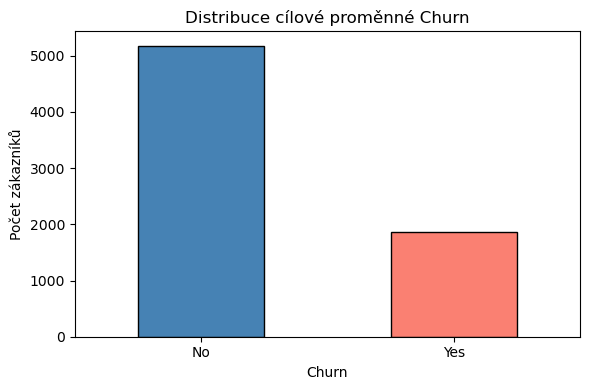

In [3]:
# Prvních 5 řádků pro vizuální kontrolu struktury
df.head()

# Datové typy — očekáváme problém u TotalCharges (string místo float)
df.dtypes

# Kontrola NaN hodnot
print("Chybějící hodnoty (NaN) po sloupcích:")
print(df.isnull().sum())
print(f"\nCelkem NaN v datasetu: {df.isnull().sum().sum()}")

# TotalCharges obsahuje prázdné stringy místo NaN — pandas je nedetekuje jako chybějící
prazdne_tc = (df["TotalCharges"] == " ").sum()
print(f"Skryté prázdné hodnoty v TotalCharges: {prazdne_tc}")

# Ověření, že všechny odpovídají zákazníkům s tenure = 0
print(f"\nRozdělení tenure u prázdných TotalCharges:")
print(df.loc[df["TotalCharges"] == " ", ["customerID", "tenure", "TotalCharges"]])

# Kontrola duplicit
print(f"Duplicitní řádky: {df.duplicated().sum()}")
print(f"Duplicitní customerID: {df['customerID'].duplicated().sum()}")

# Distribuce cílové proměnné Churn
print("Absolutní četnosti:")
print(df["Churn"].value_counts())
print(f"\nRelativní četnosti (%):")
print((df["Churn"].value_counts(normalize=True) * 100).round(1))

# Vizualizace rozložení tříd
fig, ax = plt.subplots(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black", ax=ax)
ax.set_title("Distribuce cílové proměnné Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Počet zákazníků")
ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

## 3. Popis dat a explorativní kontrola

Dataset obsahuje tři typy proměnných:
- **Numerické:** tenure, MonthlyCharges, TotalCharges (+ SeniorCitizen jako 0/1)
- **Kategoriální binární:** gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn
- **Kategoriální s více hodnotami:** MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod

V této sekci prozkoumáme základní statistiky, unikátní hodnoty kategorií a vizuální vztah klíčových proměnných s cílovou proměnnou Churn.

customerID: 7043 unikátních hodnot → ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: 2 unikátních hodnot → ['Female' 'Male']

Partner: 2 unikátních hodnot → ['Yes' 'No']

Dependents: 2 unikátních hodnot → ['No' 'Yes']

PhoneService: 2 unikátních hodnot → ['No' 'Yes']

MultipleLines: 3 unikátních hodnot → ['No phone service' 'No' 'Yes']

InternetService: 3 unikátních hodnot → ['DSL' 'Fiber optic' 'No']

OnlineSecurity: 3 unikátních hodnot → ['No' 'Yes' 'No internet service']

OnlineBackup: 3 unikátních hodnot → ['Yes' 'No' 'No internet service']

DeviceProtection: 3 unikátních hodnot → ['No' 'Yes' 'No internet service']

TechSupport: 3 unikátních hodnot → ['No' 'Yes' 'No internet service']

StreamingTV: 3 unikátních hodnot → ['No' 'Yes' 'No internet service']

StreamingMovies: 3 unikátních hodnot → ['No' 'Yes' 'No internet service']

Contract: 3 unikátních hodnot → ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: 2 unikátních hodn

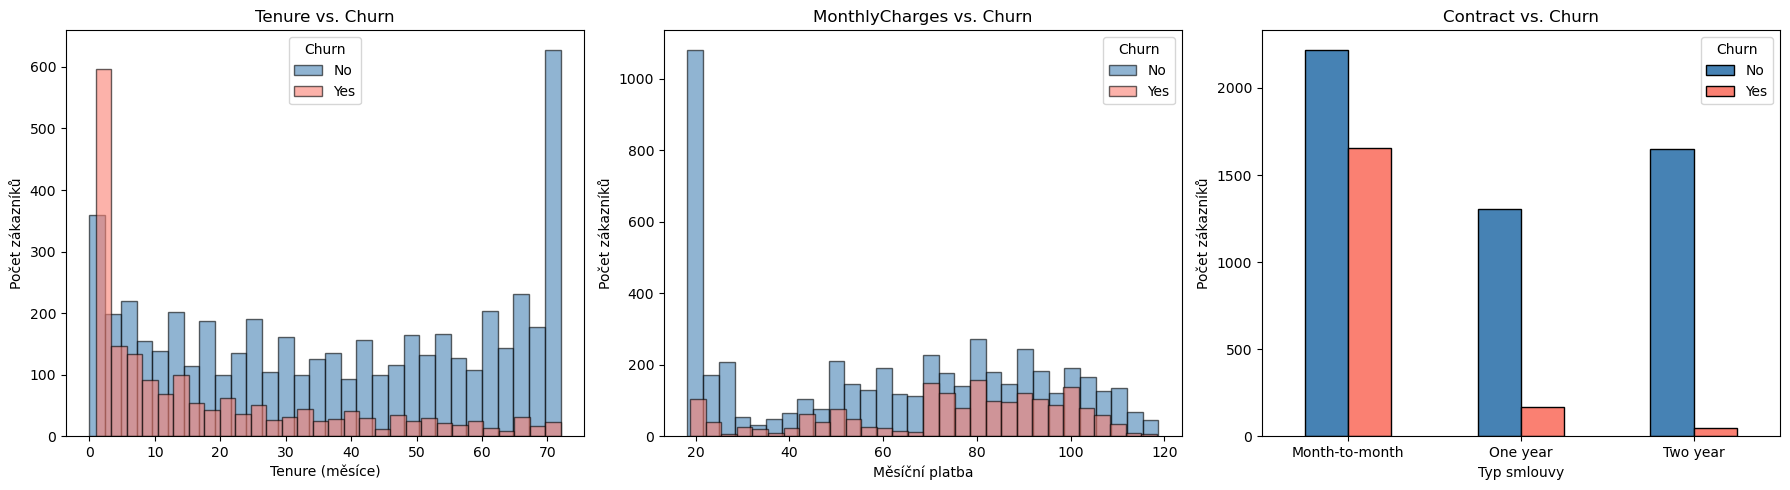

In [4]:
# Základní statistiky numerických proměnných

# TotalCharges je zatím string — statistiky uvidíme až po konverzi
df[["tenure", "MonthlyCharges", "SeniorCitizen"]].describe().round(2)

# Unikátní hodnoty všech kategoriálních proměnných
kategorialni = df.select_dtypes(include="object").columns.tolist()

for col in kategorialni:
    print(f"{col}: {df[col].nunique()} unikátních hodnot → {df[col].unique()}")
    print()


# Identifikace sloupců obsahujících hodnotu "No internet service" nebo "No phone service"

# Tyto hodnoty jsou redundantní s InternetService = "No" resp. PhoneService = "No"
for col in kategorialni:
    hodnoty = df[col].unique()
    if "No internet service" in hodnoty or "No phone service" in hodnoty:
        print(f"{col}: {list(hodnoty)}")

# Distribuce tenure podle Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure
axes[0].hist(df.loc[df["Churn"] == "No", "tenure"], bins=30, alpha=0.6, label="No", color="steelblue", edgecolor="black")
axes[0].hist(df.loc[df["Churn"] == "Yes", "tenure"], bins=30, alpha=0.6, label="Yes", color="salmon", edgecolor="black")
axes[0].set_title("Tenure vs. Churn")
axes[0].set_xlabel("Tenure (měsíce)")
axes[0].set_ylabel("Počet zákazníků")
axes[0].legend(title="Churn")

# MonthlyCharges
axes[1].hist(df.loc[df["Churn"] == "No", "MonthlyCharges"], bins=30, alpha=0.6, label="No", color="steelblue", edgecolor="black")
axes[1].hist(df.loc[df["Churn"] == "Yes", "MonthlyCharges"], bins=30, alpha=0.6, label="Yes", color="salmon", edgecolor="black")
axes[1].set_title("MonthlyCharges vs. Churn")
axes[1].set_xlabel("Měsíční platba")
axes[1].set_ylabel("Počet zákazníků")
axes[1].legend(title="Churn")

# Contract
contract_churn = df.groupby(["Contract", "Churn"]).size().unstack(fill_value=0)
contract_churn.plot(kind="bar", ax=axes[2], color=["steelblue", "salmon"], edgecolor="black")
axes[2].set_title("Contract vs. Churn")
axes[2].set_xlabel("Typ smlouvy")
axes[2].set_ylabel("Počet zákazníků")
axes[2].legend(title="Churn")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


Churn rate podle Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Churn rate podle InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

Churn rate podle SeniorCitizen:
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64
Korelační matice:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


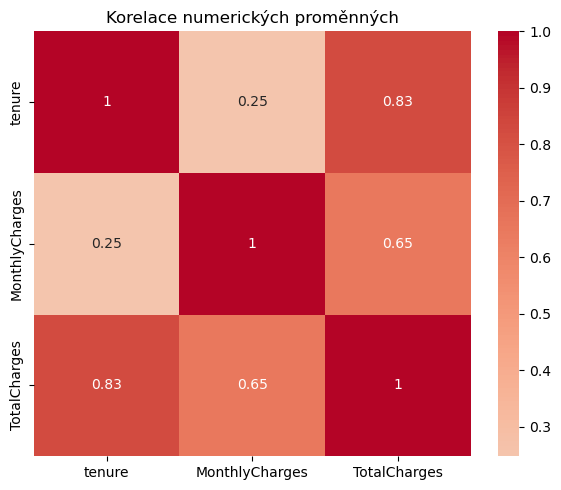

In [5]:
# Churn rate (%) podle typu smlouvy, internetové služby a seniorského věku
print("Churn rate podle Contract:")
print((df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean()) * 100).round(1))

print("\nChurn rate podle InternetService:")
print((df.groupby("InternetService")["Churn"].apply(lambda x: (x == "Yes").mean()) * 100).round(1))

print("\nChurn rate podle SeniorCitizen:")
print((df.groupby("SeniorCitizen")["Churn"].apply(lambda x: (x == "Yes").mean()) * 100).round(1))


# Korelace numerických proměnných — ověření multikolinearity tenure vs. TotalCharges

# Nejprve dočasná konverze TotalCharges na numeric (pouze pro účely korelace)
df_temp = df.copy()
df_temp["TotalCharges"] = pd.to_numeric(df_temp["TotalCharges"], errors="coerce")

korelace = df_temp[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(3)
print("Korelační matice:")
print(korelace)

# Vizualizace
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(korelace, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Korelace numerických proměnných")
plt.tight_layout()
plt.show()

# Úklid dočasné kopie
del df_temp

## 4. Leakage audit

Leakage nastává, když model při trénování nebo predikci používá informace, které by v okamžiku reálné predikce nebyly dostupné. U churn predikce existují dva hlavní typy rizika:

1. **Target leakage** — proměnná přímo nebo nepřímo prozrazuje hodnotu cílové proměnné.
2. **Train-test leakage** — informace z validační nebo testovací sady proniknou do tréninkového procesu.

V této sekci projdeme všech 21 sloupců a u každého posoudíme, zda je temporálně konzistentní.

In [6]:
# Leakage audit — posouzení všech proměnných
audit = pd.DataFrame({
    "Proměnná": df.columns,
    "Typ": [
        "identifikátor", "demografická", "demografická", "demografická", "demografická",
        "smluvní", "služba", "služba", "služba", "služba",
        "služba", "služba", "služba", "služba", "služba",
        "smluvní", "smluvní", "finanční", "finanční", "finanční",
        "target"
    ],
    "Riziko leakage": [
        "žádné – nemá predikční hodnotu",
        "žádné – stabilní atribut",
        "žádné – stabilní atribut",
        "žádné – stabilní atribut",
        "žádné – stabilní atribut",
        "žádné – známé v okamžiku predikce",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – aktuální stav služby",
        "žádné – typ smlouvy známý předem",
        "žádné – aktuální nastavení",
        "žádné – aktuální způsob platby",
        "žádné – aktuální měsíční platba",
        "žádné – kumulativní suma k datu snapshotu",
        "ANO – cílová proměnná"
    ],
    "Rozhodnutí": [
        "DROP", "ponechat", "ponechat", "ponechat", "ponechat",
        "ponechat", "ponechat", "ponechat", "ponechat", "ponechat",
        "ponechat", "ponechat", "ponechat", "ponechat", "ponechat",
        "ponechat", "ponechat", "ponechat", "ponechat", "ponechat",
        "TARGET (y)"
    ]
})

# Číslování od 1
audit.index = range(1, len(audit) + 1)
audit.index.name = "#"

print("=== LEAKAGE AUDIT — PŘEHLED PROMĚNNÝCH ===\n")
print(audit.to_string())

=== LEAKAGE AUDIT — PŘEHLED PROMĚNNÝCH ===

            Proměnná            Typ                             Riziko leakage  Rozhodnutí
#                                                                                         
1         customerID  identifikátor             žádné – nemá predikční hodnotu        DROP
2             gender   demografická                   žádné – stabilní atribut    ponechat
3      SeniorCitizen   demografická                   žádné – stabilní atribut    ponechat
4            Partner   demografická                   žádné – stabilní atribut    ponechat
5         Dependents   demografická                   žádné – stabilní atribut    ponechat
6             tenure        smluvní          žádné – známé v okamžiku predikce    ponechat
7       PhoneService         služba               žádné – aktuální stav služby    ponechat
8      MultipleLines         služba               žádné – aktuální stav služby    ponechat
9    InternetService         služba           

In [7]:
# Programová kontrola — korelace numerických proměnných s Churn
df_audit = df.copy()
df_audit["TotalCharges"] = pd.to_numeric(df_audit["TotalCharges"], errors="coerce")
df_audit["Churn_bin"] = (df_audit["Churn"] == "Yes").astype(int)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
print("Korelace numerických proměnných s Churn:")
print(df_audit[num_cols + ["Churn_bin"]].corr()["Churn_bin"].drop("Churn_bin").round(3))
print("\n→ Žádná korelace nepřesahuje |0.4| — žádný přímý leak z numerických proměnných.")


# Kontrola churn rate u kategoriálních proměnných

# Hledáme kategorii s churn rate blízkým 100 % nebo 0 % — to by naznačovalo leak
kategorialni = df.select_dtypes(include="object").columns.drop("Churn")

print("Churn rate (%) podle kategoriálních proměnných:\n")
for col in kategorialni:
    cr = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(1)
    flag = "PODEZŘELÉ" if cr.max() > 90 else ""
    print(f"{col}:{flag}")
    print(cr)
    print()

print("Žádná kategorie nemá churn rate blízký 100 % — target leakage nepotvrzen.")

Korelace numerických proměnných s Churn:
tenure           -0.352
MonthlyCharges    0.193
TotalCharges     -0.199
SeniorCitizen     0.151
Name: Churn_bin, dtype: float64

→ Žádná korelace nepřesahuje |0.4| — žádný přímý leak z numerických proměnných.
Churn rate (%) podle kategoriálních proměnných:

customerID:PODEZŘELÉ
customerID
0002-ORFBO      0.0
0003-MKNFE      0.0
0004-TLHLJ    100.0
0011-IGKFF    100.0
0013-EXCHZ    100.0
              ...  
9987-LUTYD      0.0
9992-RRAMN    100.0
9992-UJOEL      0.0
9993-LHIEB      0.0
9995-HOTOH      0.0
Name: Churn, Length: 7043, dtype: float64

gender:
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64

Partner:
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64

Dependents:
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     24.9
Yes    26.7
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Na

In [8]:
# Úklid dočasných proměnných
del df_audit

### Závěr leakage auditu

- **customerID** bude odstraněn — unikátní identifikátor bez predikční hodnoty. Kdyby zůstal, model by si mohl zapamatovat konkrétní zákazníky.
- **Churn** je cílová proměnná — bude zakódována jako 1/0 a oddělena jako target (y).
- **Žádná z ostatních 19 proměnných nepředstavuje target leakage.** Všechny zachycují stav zákazníka v okamžiku snapshotu, tedy informaci dostupnou před rozhodnutím o odchodu.
- **Train-test leakage** ošetříme v sekci 7 (preprocessing pipeline) — všechny fitované transformace budou aplikovány výhradně na trénovací sadě.

## 5. Čištění dat před splitem

Před rozdělením dat provedeme deterministické kroky čištění, které nejsou "učené z dat" a nemohou způsobit leakage:

1. Odstranění 11 řádků s prázdným TotalCharges (zákazníci s tenure = 0, bez jakékoli historie)
2. Konverze TotalCharges z textu na numerický typ
3. Encoding cílové proměnné Churn (Yes → 1, No → 0)
4. Odstranění customerID (identifikátor bez predikční hodnoty)

Tyto kroky jsou bezpečné před splitem, protože se jedná o opravu vadných dat a deterministické přemapování hodnot — žádný z nich se neučí statistiky z dat.

In [9]:
# Počet řádků před čištěním
print(f"Řádků před čištěním: {df.shape[0]}")

# Odstranění 11 řádků s prázdným TotalCharges (tenure = 0, žádná historie)
df = df[df["TotalCharges"] != " "].copy()

print(f"Řádků po čištění: {df.shape[0]}")
print(f"Odstraněno: {7043 - df.shape[0]} řádků")

# Konverze TotalCharges z textu na float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Ověření úspěšnosti konverze
print(f"Dtype TotalCharges: {df['TotalCharges'].dtype}")
print(f"Zbývající NaN v TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"\nZákladní statistiky TotalCharges:")
print(df["TotalCharges"].describe().round(2))

# Encoding cílové proměnné Churn: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Ověření
print("Distribuce Churn po encodingu:")
print(df["Churn"].value_counts())
print(f"\nDtype Churn: {df['Churn'].dtype}")

# Odstranění customerID — identifikátor bez predikční hodnoty
df = df.drop(columns=["customerID"])

print(f"Zbývající počet sloupců: {df.shape[1]}")
print(f"Sloupce: {list(df.columns)}")

# Finální kontrola čistého datasetu před splitem
print(f"Shape: {df.shape}")
print(f"NaN celkem: {df.isnull().sum().sum()}")
print(f"Dtypes:\n{df.dtypes}")


Řádků před čištěním: 7043
Řádků po čištění: 7032
Odstraněno: 11 řádků
Dtype TotalCharges: float64
Zbývající NaN v TotalCharges: 0

Základní statistiky TotalCharges:
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80
Name: TotalCharges, dtype: float64
Distribuce Churn po encodingu:
Churn
0    5163
1    1869
Name: count, dtype: int64

Dtype Churn: int64
Zbývající počet sloupců: 20
Sloupce: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Shape: (7032, 20)
NaN celkem: 0
Dtypes:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
Multip

### Shrnutí čištění

- Odstraněno **11 řádků** s prázdným TotalCharges (zákazníci bez historie)
- TotalCharges konvertováno z textu na **float64**
- Churn překódován na **1/0** (int64)
- customerID **odstraněno**
- Dataset připraven ke splitu: **7 032 řádků, 20 sloupců** (19 features + 1 target)

## 6. Návrh a provedení splitu

### Zdůvodnění zvoleného splitu

Dataset je statický snapshot — neobsahuje časový vývoj, proto není nutný chronologický split. Použijeme **stratifikovaný náhodný split** podle cílové proměnné Churn, aby poměr tříd zůstal zachován ve všech sadách.

**Rozdělení:**
- Trénovací data: ~80 %
- Validační data: ~15 %
- Testovací data: ~5 % (dále dělitelná na T1 a T2, každá ~2,5 %)

**Postup:**
1. Nejprve oddělíme 5 % dat jako testovací sadu
2. Zbylých 95 % rozdělíme na trénovací (~80 % celku) a validační (~15 % celku)
3. Testovací sadu rozdělíme na T1 a T2 (každá ~2,5 % celku)

**Pravidla:**
- Testovací data nebudou použita při trénování ani ladění modelu
- T1 slouží pro finální vyhodnocení, T2 jako nezávislá kontrola
- Všechny splity používají stratifikaci podle Churn
- Reprodukovatelnost zajištěna pomocí random_state = 42

In [10]:
from sklearn.model_selection import train_test_split

# Oddělení features (X) a targetu (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Krok 1: oddělení testovací sady (5 % celku)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=RANDOM_STATE
)

# Krok 2: rozdělení zbytku na train (~80 % celku) a validation (~15 % celku)
# Z 95 % zbytku potřebujeme validaci = 15/95 ≈ 0.1579
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=15/95, stratify=y_temp, random_state=RANDOM_STATE
)

# Krok 3: rozdělení testovací sady na T1 a T2 (každá ~2,5 % celku)
X_test_t1, X_test_t2, y_test_t1, y_test_t2 = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=RANDOM_STATE
)

# Explicitní kopie — prevence SettingWithCopyWarning při preprocessingu v sekci 7
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_test_t1 = X_test_t1.copy()
X_test_t2 = X_test_t2.copy()

print(f"Celkem řádků: {len(df)}")
print(f"Train:      {len(X_train)} ({len(X_train)/len(df)*100:.1f} %)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(df)*100:.1f} %)")
print(f"Test:       {len(X_test)} ({len(X_test)/len(df)*100:.1f} %)")
print(f"  - T1:     {len(X_test_t1)} ({len(X_test_t1)/len(df)*100:.1f} %)")
print(f"  - T2:     {len(X_test_t2)} ({len(X_test_t2)/len(df)*100:.1f} %)")

Celkem řádků: 7032
Train:      5625 (80.0 %)
Validation: 1055 (15.0 %)
Test:       352 (5.0 %)
  - T1:     176 (2.5 %)
  - T2:     176 (2.5 %)


In [11]:
# Kontrola zachování distribuce Churn ve všech sadách
print("Podíl Churn = 1 v jednotlivých sadách:\n")
print(f"Celý dataset: {y.mean()*100:.1f} %")
print(f"Train:        {y_train.mean()*100:.1f} %")
print(f"Validation:   {y_val.mean()*100:.1f} %")
print(f"Test:         {y_test.mean()*100:.1f} %")
print(f"  - T1:       {y_test_t1.mean()*100:.1f} %")
print(f"  - T2:       {y_test_t2.mean()*100:.1f} %")
print("\n→ Stratifikace zachována — podíl churnu je konzistentní napříč sadami.")

Podíl Churn = 1 v jednotlivých sadách:

Celý dataset: 26.6 %
Train:        26.6 %
Validation:   26.5 %
Test:         26.7 %
  - T1:       26.7 %
  - T2:       26.7 %

→ Stratifikace zachována — podíl churnu je konzistentní napříč sadami.


In [12]:
# Spojení features a targetu zpět do jednoho DataFrame pro uložení
train = pd.concat([X_train, y_train], axis=1)
validation = pd.concat([X_val, y_val], axis=1)
test = pd.concat([X_test, y_test], axis=1)
test_t1 = pd.concat([X_test_t1, y_test_t1], axis=1)
test_t2 = pd.concat([X_test_t2, y_test_t2], axis=1)

print(f"Train shape:      {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Test shape:       {test.shape}")
print(f"Test T1 shape:    {test_t1.shape}")
print(f"Test T2 shape:    {test_t2.shape}")

Train shape:      (5625, 20)
Validation shape: (1055, 20)
Test shape:       (352, 20)
Test T1 shape:    (176, 20)
Test T2 shape:    (176, 20)


In [13]:
import os

# Vytvoření složky pro pre-processed data
os.makedirs("data/pre-processed", exist_ok=True)

# Uložení splitů do CSV
train.to_csv("data/pre-processed/train.csv", index=False)
validation.to_csv("data/pre-processed/validation.csv", index=False)
test.to_csv("data/pre-processed/test.csv", index=False)
test_t1.to_csv("data/pre-processed/test_t1.csv", index=False)
test_t2.to_csv("data/pre-processed/test_t2.csv", index=False)

print("Uložené soubory:")
for f in ["train.csv", "validation.csv", "test.csv", "test_t1.csv", "test_t2.csv"]:
    size = os.path.getsize(f"data/pre-processed/{f}") / 1024
    print(f"  data/pre-processed/{f}: {size:.1f} KB")

Uložené soubory:
  data/pre-processed/train.csv: 696.3 KB
  data/pre-processed/validation.csv: 130.0 KB
  data/pre-processed/test.csv: 44.3 KB
  data/pre-processed/test_t1.csv: 22.0 KB
  data/pre-processed/test_t2.csv: 22.5 KB


### Shrnutí splitu

- Split proveden stratifikovaně podle Churn s random_state = 42
- Distribuce tříd zachována ve všech sadách
- Uloženo 5 souborů: train.csv, validation.csv, test.csv, test_t1.csv, test_t2.csv
- **Testovací data nebudou použita při trénování ani ladění modelu**
- Validační sada slouží pro porovnání benchmarků v benchmark.ipynb

In [14]:
# Identifikace typů sloupců pro preprocessing
# Pracujeme s X_train, X_val, X_test, X_test_t1, X_test_t2 z předchozí sekce

# Numerické sloupce — budou škálovány
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Binární sloupce (Yes/No) — label encoding 0/1
bin_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

# Sloupce se třemi hodnotami obsahující "No internet/phone service" — sloučení → binární
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

# Ordinální sloupec — přirozené pořadí
ord_cols = ["Contract"]

# Nominální sloupce — one-hot encoding
nom_cols = ["InternetService", "PaymentMethod"]

# SeniorCitizen je již numerický (0/1) — ponecháme beze změny
print("Numerické:  ", num_cols)
print("Binární:    ", bin_cols)
print("Služby:     ", service_cols)
print("Ordinální:  ", ord_cols)
print("Nominální:  ", nom_cols)
print("Beze změny: ", ["SeniorCitizen"])
print(f"\nCelkem: {len(num_cols) + len(bin_cols) + len(service_cols) + len(ord_cols) + len(nom_cols) + 1} sloupců")

Numerické:   ['tenure', 'MonthlyCharges', 'TotalCharges']
Binární:     ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Služby:      ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Ordinální:   ['Contract']
Nominální:   ['InternetService', 'PaymentMethod']
Beze změny:  ['SeniorCitizen']

Celkem: 19 sloupců


In [15]:
# Sloučení "No internet service" a "No phone service" s "No"
# Důvod: tyto hodnoty jsou redundantní s InternetService = "No" resp. PhoneService = "No"
# Jde o deterministické přemapování — bezpečné aplikovat na všechny sady

sady = {
    "train": X_train,
    "val": X_val,
    "test": X_test,
    "test_t1": X_test_t1,
    "test_t2": X_test_t2
}

for nazev, sada in sady.items():
    for col in service_cols:
        sada[col] = sada[col].replace({
            "No internet service": "No",
            "No phone service": "No"
        })

# Ověření — po sloučení by měly zůstat pouze hodnoty Yes/No
print("Unikátní hodnoty po sloučení (train):\n")
for col in service_cols:
    print(f"  {col}: {list(X_train[col].unique())}")

Unikátní hodnoty po sloučení (train):

  MultipleLines: ['Yes', 'No']
  OnlineSecurity: ['No', 'Yes']
  OnlineBackup: ['No', 'Yes']
  DeviceProtection: ['No', 'Yes']
  TechSupport: ['No', 'Yes']
  StreamingTV: ['No', 'Yes']
  StreamingMovies: ['Yes', 'No']


In [16]:
# Label encoding binárních proměnných (Yes/No → 1/0, Female/Male → 1/0)
# Deterministické mapování — bezpečné aplikovat na všechny sady

# Definice mapování
bin_mapping = {
    "gender": {"Female": 1, "Male": 0},
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0}
}

# Mapování pro service sloupce (po sloučení jsou také binární)
service_mapping = {"Yes": 1, "No": 0}

for nazev, sada in sady.items():
    # Binární sloupce
    for col, mapping in bin_mapping.items():
        sada[col] = sada[col].map(mapping)
    # Service sloupce
    for col in service_cols:
        sada[col] = sada[col].map(service_mapping)

# Ověření na train sadě
print("Dtypes po label encodingu (train):\n")
for col in bin_cols + service_cols:
    print(f"  {col}: {X_train[col].dtype}, unikátní: {sorted(X_train[col].unique())}")

Dtypes po label encodingu (train):

  gender: int64, unikátní: [0, 1]
  Partner: int64, unikátní: [0, 1]
  Dependents: int64, unikátní: [0, 1]
  PhoneService: int64, unikátní: [0, 1]
  PaperlessBilling: int64, unikátní: [0, 1]
  MultipleLines: int64, unikátní: [0, 1]
  OnlineSecurity: int64, unikátní: [0, 1]
  OnlineBackup: int64, unikátní: [0, 1]
  DeviceProtection: int64, unikátní: [0, 1]
  TechSupport: int64, unikátní: [0, 1]
  StreamingTV: int64, unikátní: [0, 1]
  StreamingMovies: int64, unikátní: [0, 1]


In [17]:
# Ordinal encoding proměnné Contract
# Přirozené pořadí: Month-to-month (0) < One year (1) < Two year (2)
contract_mapping = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

for nazev, sada in sady.items():
    sada["Contract"] = sada["Contract"].map(contract_mapping)

# Ověření
print("Contract po ordinal encodingu (train):")
print(X_train["Contract"].value_counts().sort_index())

Contract po ordinal encodingu (train):
Contract
0    3117
1    1181
2    1327
Name: count, dtype: int64


In [18]:
# One-hot encoding pro InternetService a PaymentMethod
# Fitujeme na train sadě — zajistí konzistentní sloupce napříč sadami

from sklearn.preprocessing import OneHotEncoder

# Inicializace encoderu — drop="first" pro prevenci multikolinearity
ohe = OneHotEncoder(drop="first", sparse_output=False, dtype=int)

# Fit pouze na trénovací sadě
ohe.fit(X_train[nom_cols])

# Názvy nových sloupců
ohe_feature_names = ohe.get_feature_names_out(nom_cols)
print(f"Nové sloupce po one-hot encodingu: {list(ohe_feature_names)}")

# Transformace všech sad — vytvoření nových DataFramů místo modifikace starých
def apply_ohe(X, ohe, nom_cols, ohe_feature_names):
    ohe_data = pd.DataFrame(
        ohe.transform(X[nom_cols]),
        columns=ohe_feature_names,
        index=X.index
    )
    return pd.concat([X.drop(columns=nom_cols), ohe_data], axis=1)

X_train = apply_ohe(X_train, ohe, nom_cols, ohe_feature_names)
X_val = apply_ohe(X_val, ohe, nom_cols, ohe_feature_names)
X_test = apply_ohe(X_test, ohe, nom_cols, ohe_feature_names)
X_test_t1 = apply_ohe(X_test_t1, ohe, nom_cols, ohe_feature_names)
X_test_t2 = apply_ohe(X_test_t2, ohe, nom_cols, ohe_feature_names)

print(f"\nPočet sloupců po one-hot encodingu: {X_train.shape[1]}")
print(f"Sloupce: {list(X_train.columns)}")

Nové sloupce po one-hot encodingu: ['InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Počet sloupců po one-hot encodingu: 22
Sloupce: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [19]:
# StandardScaler na numerické sloupce — fit POUZE na trénovací sadě
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit na train
scaler.fit(X_train[num_cols])

print("Parametry scaleru (naučené z train):")
for col, mean, std in zip(num_cols, scaler.mean_, scaler.scale_):
    print(f"  {col}: mean = {mean:.2f}, std = {std:.2f}")

# Transformace všech sad
for sada in [X_train, X_val, X_test, X_test_t1, X_test_t2]:
    sada[num_cols] = scaler.transform(sada[num_cols])

# Ověření — train by měl mít mean ≈ 0 a std ≈ 1
print(f"\nKontrola train po scalingu:")
print(X_train[num_cols].describe().round(3).loc[["mean", "std"]])

Parametry scaleru (naučené z train):
  tenure: mean = 32.15, std = 24.51
  MonthlyCharges: mean = 64.62, std = 30.01
  TotalCharges: mean = 2251.78, std = 2252.20

Kontrola train po scalingu:
      tenure  MonthlyCharges  TotalCharges
mean    -0.0            -0.0           0.0
std      1.0             1.0           1.0


In [20]:
# Finální kontrola zpracovaných dat
print("=== FINÁLNÍ KONTROLA PREPROCESSINGU ===\n")

print(f"X_train:    {X_train.shape}")
print(f"X_val:      {X_val.shape}")
print(f"X_test:     {X_test.shape}")
print(f"X_test_t1:  {X_test_t1.shape}")
print(f"X_test_t2:  {X_test_t2.shape}")

print(f"\nNaN celkem (train): {X_train.isnull().sum().sum()}")
print(f"NaN celkem (val):   {X_val.isnull().sum().sum()}")
print(f"NaN celkem (test):  {X_test.isnull().sum().sum()}")

print(f"\nDtypes (train):")
print(X_train.dtypes)

=== FINÁLNÍ KONTROLA PREPROCESSINGU ===

X_train:    (5625, 22)
X_val:      (1055, 22)
X_test:     (352, 22)
X_test_t1:  (176, 22)
X_test_t2:  (176, 22)

NaN celkem (train): 0
NaN celkem (val):   0
NaN celkem (test):  0

Dtypes (train):
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
Contract                                   int64
PaperlessBilling                           int64
MonthlyCharges              

In [21]:
# Náhled finálních zpracovaných dat — prvních 5 řádků train sady
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
522,0,0,1,1,0.932351,1,1,0,0,0,...,1,0,0,0.695784,1.092982,1,0,0,0,0
6243,1,0,1,1,1.625898,1,1,1,1,1,...,1,2,1,0.632465,1.646174,0,0,1,0,0
208,1,0,0,0,-0.536335,1,0,1,0,1,...,1,0,1,1.398952,-0.140899,1,0,0,1,0
1092,0,0,1,0,1.544304,1,0,1,1,1,...,0,2,0,0.010944,1.008554,0,0,1,0,0
5211,1,0,1,0,-0.985101,1,1,0,0,0,...,1,0,1,0.675788,-0.660168,1,0,0,1,0


In [22]:
# Uložení zpracovaných sad do CSV
# Spojení features a targetu zpět do jednoho DataFrame

train_processed = pd.concat([X_train, y_train], axis=1)
val_processed = pd.concat([X_val, y_val], axis=1)
test_processed = pd.concat([X_test, y_test], axis=1)
test_t1_processed = pd.concat([X_test_t1, y_test_t1], axis=1)
test_t2_processed = pd.concat([X_test_t2, y_test_t2], axis=1)

os.makedirs("data/processed", exist_ok=True)

train_processed.to_csv("data/processed/train_processed.csv", index=False)
val_processed.to_csv("data/processed/validation_processed.csv", index=False)
test_processed.to_csv("data/processed/test_processed.csv", index=False)
test_t1_processed.to_csv("data/processed/test_t1_processed.csv", index=False)
test_t2_processed.to_csv("data/processed/test_t2_processed.csv", index=False)

print("Uložené zpracované soubory:")
for f in os.listdir("data/processed"):
    size = os.path.getsize(f"data/processed/{f}") / 1024
    print(f"  data/processed/{f}: {size:.1f} KB")

Uložené zpracované soubory:
  data/processed/test_processed.csv: 34.6 KB
  data/processed/test_t1_processed.csv: 17.5 KB
  data/processed/test_t2_processed.csv: 17.5 KB
  data/processed/train_processed.csv: 548.0 KB
  data/processed/validation_processed.csv: 102.9 KB


### Shrnutí preprocessingu

**Provedené transformace:**
1. Sloučení "No internet/phone service" s "No" → 7 sloupců převedeno na binární
2. Label encoding 12 binárních proměnných (Yes/No → 1/0)
3. Ordinal encoding Contract (Month-to-month=0, One year=1, Two year=2)
4. One-hot encoding InternetService a PaymentMethod (fit na train, drop="first")
5. StandardScaler na tenure, MonthlyCharges, TotalCharges (fit na train)

**Prevence leakage:**
- OneHotEncoder fitován pouze na train sadě
- StandardScaler fitován pouze na train sadě
- Deterministické mapování (label, ordinal) aplikováno uniformně

**Uložení:**
- Pre-processed splity (po čištění, před encodingem a scalingem): `data/pre-processed/`
- Processed splity (po kompletní pipeline): `data/processed/`

## 8. Shrnutí a další kroky

### Co bylo metodicky důležité

- **Pořadí kroků:** Deterministické čištění (odstranění vadných řádků, konverze typů, encoding targetu, drop customerID) bylo provedeno před splitem. Transformace učené z dat (OneHotEncoder, StandardScaler) byly fitovány výhradně na trénovací sadě.
- **Leakage audit:** Žádná z 19 vstupních proměnných nepředstavuje target leakage. Všechny zachycují stav zákazníka dostupný v okamžiku predikce.
- **Stratifikace:** Split zachovává poměr tříd Churn (~26,5 % / ~73,5 %) ve všech sadách.
- **Reprodukovatelnost:** Všechny kroky s náhodností používají random_state = 42.

### Co bylo obtížné

- **TotalCharges** vyžadoval dvě opravy najednou — konverzi z textu na číslo a ošetření 11 skrytých prázdných hodnot, které pandas nedetekoval jako NaN.
- **Sloupce se třemi hodnotami** (Yes / No / No internet service) — rozhodnutí sloučit "No internet service" s "No" vyžadovalo posouzení, zda jde o redundanci s proměnnou InternetService. Po ověření ano — zákazník bez internetové služby logicky nemůže využívat žádnou z doplňkových služeb.

### Další kroky (benchmark.ipynb)

1. **Naivní baseline:** pravidlové řešení (Contract = Month-to-month AND tenure ≤ 12)
2. **ML benchmark:** logistická regrese s class_weight="balanced"
3. **Vyhodnocení:** F1-score, ROC-AUC, PR-AUC, confusion matrix — vše na validační sadě

### Plánované rozšíření (HW3+)

- Kalibrace pravděpodobností (Platt scaling / isotonic regression)
- Cost-sensitive hodnocení s asymetrií nákladů FN vs. FP
- Top-K selection a Precision@K pro simulaci omezeného retenčního budgetu
- Pokročilé modely: Random Forest, XGBoost / LightGBM